# Exploratory Data Analysis in Python

### importing libraries that we will use

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

### Getting to know a dataset

In [2]:
#read_dataset
df = pd.read_csv('world-happiness-report.csv')

In [3]:
# show first 10 rows of dataset
df.head(10)

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
0,Afghanistan,2008,3.724,7.370,0.451,50.80,0.718,0.168,0.882,0.518,0.258
1,Afghanistan,2009,4.402,7.540,0.552,51.20,0.679,0.190,0.850,0.584,0.237
2,Afghanistan,2010,4.758,7.647,0.539,51.60,0.600,0.121,0.707,0.618,0.275
3,Afghanistan,2011,3.832,7.620,0.521,51.92,0.496,0.162,0.731,0.611,0.267
4,Afghanistan,2012,3.783,7.705,0.521,52.24,0.531,0.236,0.776,0.710,0.268
5,Afghanistan,2013,3.572,7.725,0.484,52.56,0.578,0.061,0.823,0.621,0.273
6,Afghanistan,2014,3.131,7.718,0.526,52.88,0.509,0.104,0.871,0.532,0.375
7,Afghanistan,2015,3.983,7.702,0.529,53.20,0.389,0.080,0.881,0.554,0.339
8,Afghanistan,2016,4.220,7.697,0.559,53.00,0.523,0.042,0.793,0.565,0.348
9,Afghanistan,2017,2.662,7.697,0.491,52.80,0.427,-0.121,0.954,0.496,0.371


In [4]:
# information about data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1949 entries, 0 to 1948
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country name                      1949 non-null   object 
 1   year                              1949 non-null   int64  
 2   Life Ladder                       1949 non-null   float64
 3   Log GDP per capita                1913 non-null   float64
 4   Social support                    1936 non-null   float64
 5   Healthy life expectancy at birth  1894 non-null   float64
 6   Freedom to make life choices      1917 non-null   float64
 7   Generosity                        1860 non-null   float64
 8   Perceptions of corruption         1839 non-null   float64
 9   Positive affect                   1927 non-null   float64
 10  Negative affect                   1933 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 167.6+ KB


In [5]:
#Providing summary statistics for numerical columns.
df.describe()

,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
count,1949.000000,1949.000000,1913.000000,1936.000000,1894.000000,1917.000000,1860.000000,1839.000000,1927.000000,1933.000000
mean,2013.216008,5.466705,9.368453,0.812552,63.359374,0.742558,0.000103,0.747125,0.710003,0.268544
std,4.166828,1.115711,1.154084,0.118482,7.510245,0.142093,0.162215,0.186789,0.107100,0.085168
min,2005.000000,2.375000,6.635000,0.290000,32.300000,0.258000,-0.335000,0.035000,0.322000,0.083000
25%,2010.000000,4.640000,8.464000,0.749750,58.685000,0.647000,-0.113000,0.690000,0.625500,0.206000
50%,2013.000000,5.386000,9.460000,0.835500,65.200000,0.763000,-0.025500,0.802000,0.722000,0.258000
75%,2017.000000,6.283000,10.353000,0.905000,68.590000,0.856000,0.091000,0.872000,0.799000,0.320000
max,2020.000000,8.019000,11.648000,0.987000,77.100000,0.985000,0.698000,0.983000,0.944000,0.705000


In [6]:
# Count the number of missing values in each column
df.isna().sum()

Country name                          0
year                                  0
Life Ladder                           0
Log GDP per capita                   36
Social support                       13
Healthy life expectancy at birth     55
Freedom to make life choices         32
Generosity                           89
Perceptions of corruption           110
Positive affect                      22
Negative affect                      16
dtype: int64

In [7]:
#Counting the number of countries in our data
num_countries = df['Country name'].nunique()
num_countries

166

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Life Ladder', ylabel='Count'>

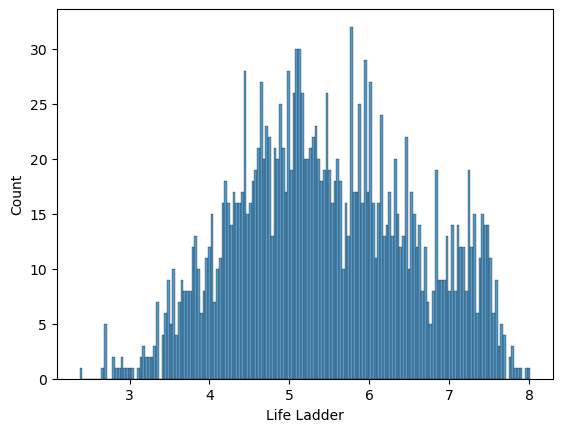

In [8]:
#Let's explore the distribution of Life Ladder by our countries
custom_bins=np.linspace(df['Life Ladder'].min(), df['Life Ladder'].max(), num=num_countries)
sns.histplot(x='Life Ladder', data=df, bins=custom_bins)

### Let's look next on how level of happiness has changed over years

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


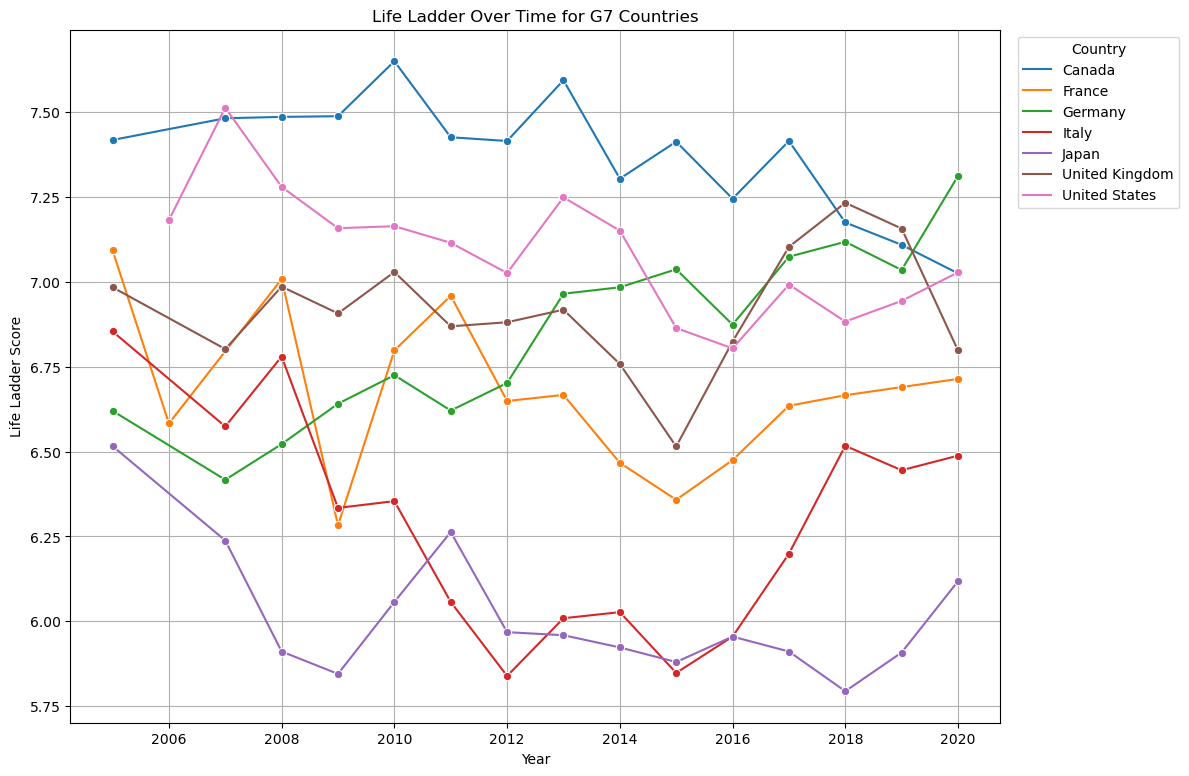

In [9]:
g7_countries = ['Canada', 'France', 'Germany', 'Italy', 'Japan', 'United Kingdom', 'United States']

# Filter the DataFrame for G7 countries
df_g7 = df[df['Country name'].isin(g7_countries)]
plt.figure(figsize=(12, 9))
sns.lineplot(data=df_g7, x='year', y='Life Ladder', hue='Country name', marker='o')
plt.title('Life Ladder Over Time for G7 Countries')
plt.xlabel('Year')
plt.ylabel('Life Ladder Score')
plt.legend(title="Country", loc='upper right', bbox_to_anchor=(1.2, 1)) 
plt.grid(True)
plt.show()

### Let's explore top 30 countries based on life ladder

In [37]:
df_mean = df.groupby('Country name')[['Life Ladder',
'Log GDP per capita','Social support','Healthy life expectancy at birth',
'Freedom to make life choices','Generosity','Perceptions of corruption','Positive affect',
'Negative affect']].mean()

top_30 = df_mean.sort_values(by='Life Ladder', ascending=False).head(30)
top_30

,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
Country name,,,,,,,,,
Denmark,7.680400,10.879200,0.957133,71.169333,0.945067,0.170929,0.200467,0.813733,0.197200
Finland,7.597154,10.749923,0.949000,71.180000,0.939692,0.003077,0.249000,0.774231,0.186462
Switzerland,7.548300,11.095400,0.943600,73.334000,0.924700,0.106400,0.305900,0.803800,0.190300
Norway,7.512400,11.039100,0.950500,72.670000,0.954400,0.136100,0.344200,0.829600,0.200300
Netherlands,7.466286,10.886786,0.933500,71.707143,0.907429,0.276385,0.414929,0.842500,0.213000
Iceland,7.446500,10.860625,0.977500,72.865000,0.931500,0.258143,0.701000,0.870875,0.162750
Canada,7.376333,10.748267,0.935571,72.694667,0.927933,0.217800,0.417867,0.849600,0.250933
Sweden,7.369467,10.819600,0.927933,72.110667,0.929600,0.148071,0.262714,0.819400,0.180400
New Zealand,7.310286,10.583000,0.952929,72.428571,0.923143,0.256429,0.266214,0.845857,0.199857


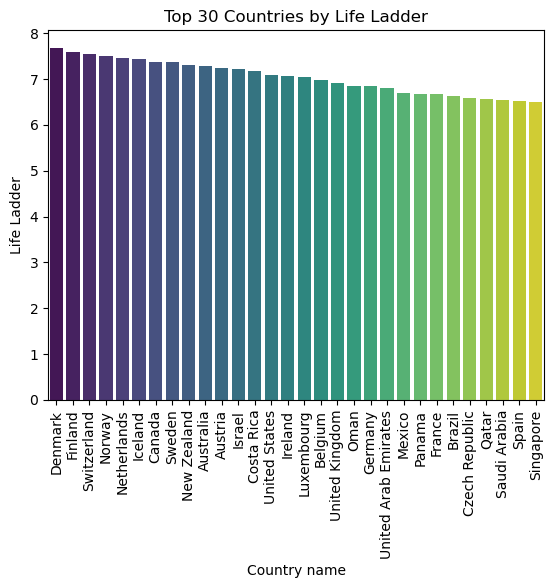

In [38]:
sns.barplot(data=top_30, x=top_30.index, y='Life Ladder', palette="viridis")
plt.xticks(rotation=90)
plt.title("Top 30 Countries by Life Ladder")
plt.show()

### Oppositely bottom 30 based on life ladder

In [39]:
# Show bottom 60 countries sorted by 'Life Ladder' (Ascending)
bottom_30 = df_mean.sort_values(by='Life Ladder', ascending=True).head(30)
bottom_60

,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
Country name,,,,,,,,,
South Sudan,3.402000,NaN,0.554750,50.410000,0.493750,NaN,0.749500,0.600250,0.486000
Central African Republic,3.515000,6.961000,0.402400,43.356000,0.680400,0.027000,0.842000,0.561600,0.391400
Burundi,3.548200,6.722400,0.417800,50.916000,0.450800,-0.036600,0.732400,0.618400,0.244200
Togo,3.555000,7.239222,0.456000,52.837778,0.623333,-0.030778,0.803222,0.561667,0.420000
Afghanistan,3.594667,7.650833,0.508417,52.266667,0.518167,0.070083,0.843333,0.548667,0.326500
Rwanda,3.654417,7.451083,0.619417,57.586667,0.867917,0.012364,0.186000,0.725917,0.223667
Tanzania,3.697333,7.700200,0.763800,54.173333,0.714067,0.132400,0.767733,0.723800,0.207600
Zimbabwe,3.882600,7.850333,0.799400,50.233333,0.587933,-0.083000,0.844200,0.717733,0.224400
Yemen,3.912250,8.102700,0.739833,54.866667,0.622417,-0.126200,0.824667,0.530500,0.293583


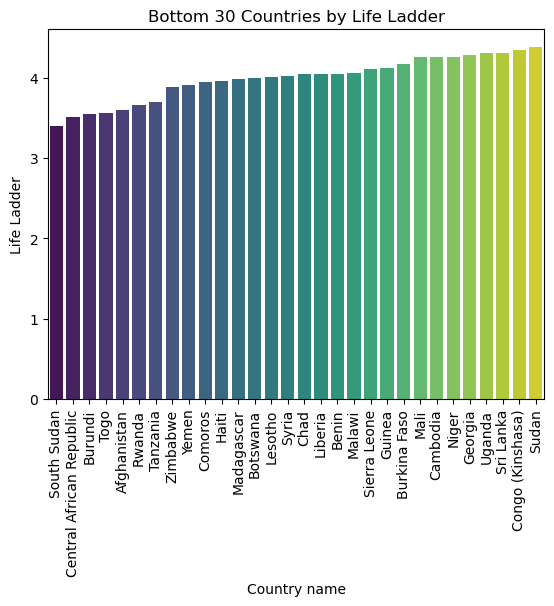

In [40]:
sns.barplot(data=bottom_30, x=bottom_30.index, y='Life Ladder', palette="viridis")
plt.xticks(rotation=90)
plt.title("Bottom 30 Countries by Life Ladder")
plt.show()

### Let's measure how overall happiness rate increase/decrease over the years(from minimum year of appearance to the last year of appearance)

In [13]:
# Group by Country and find the min/max year dynamically
df_min_max = df.groupby("Country name")["year"].agg(["min", "max"]).reset_index()
# Merge with original data to get the corresponding 'Life Ladder' values
df_min = df.merge(df_min_max[['Country name', 'min']], left_on=['Country name', 'year'], right_on=['Country name', 'min'])
df_max = df.merge(df_min_max[['Country name', 'max']], left_on=['Country name', 'year'], right_on=['Country name', 'max'])
# Rename columns for clarity
df_min = df_min.rename(columns={"Life Ladder": "Life Ladder_Min"})
df_max = df_max.rename(columns={"Life Ladder": "Life Ladder_Max"})
# Merge min and max data
df_change = df_min[['Country name', 'Life Ladder_Min']].merge(
    df_max[['Country name', 'Life Ladder_Max']], on="Country name"
)
# Compute the absolute change
df_change["Life Ladder Change"] = df_change["Life Ladder_Max"] - df_change["Life Ladder_Min"]
# Sort by largest change
df_change = df_change.sort_values(by="Life Ladder Change", ascending=False)

In [14]:
top_30 = df_change.sort_values(by='Life Ladder Change', ascending=False).head(30)
top_30

,Country name,Life Ladder_Min,Life Ladder_Max,Life Ladder Change
20,Bulgaria,3.844,5.598,1.754
106,Nicaragua,4.460,6.113,1.653
78,Kyrgyzstan,4.641,6.250,1.609
80,Latvia,4.710,6.229,1.519
51,Georgia,3.675,5.123,1.448
83,Liberia,3.701,5.121,1.420
97,Mongolia,4.609,6.011,1.402
32,Congo (Brazzaville),3.820,5.213,1.393
24,Cameroon,3.851,5.241,1.390
127,Serbia,4.750,6.042,1.292


In [15]:
bottom_30 = df_change.sort_values(by='Life Ladder Change', ascending=False).head(30)
top_30

,Country name,Life Ladder_Min,Life Ladder_Max,Life Ladder Change
20,Bulgaria,3.844,5.598,1.754
106,Nicaragua,4.460,6.113,1.653
78,Kyrgyzstan,4.641,6.250,1.609
80,Latvia,4.710,6.229,1.519
51,Georgia,3.675,5.123,1.448
83,Liberia,3.701,5.121,1.420
97,Mongolia,4.609,6.011,1.402
32,Congo (Brazzaville),3.820,5.213,1.393
24,Cameroon,3.851,5.241,1.390
127,Serbia,4.750,6.042,1.292


### How unstable happiness was across the years

In [43]:
df_std = df.groupby("Country name")["Life Ladder"].std().reset_index()
df_std.rename(columns={"Life Ladder": "Life Ladder_StdDev"}, inplace=True)
# Sort by highest fluctuation
df_std = df_std.sort_values(by="Life Ladder_StdDev", ascending=False)
print(df_std.head(10))

    Country name  Life Ladder_StdDev
161    Venezuela            1.064194
144        Syria            0.969029
3         Angola            0.815286
14         Benin            0.808925
0    Afghanistan            0.740986
83       Liberia            0.710458
165     Zimbabwe            0.680249
70   Ivory Coast            0.679027
56        Guinea            0.678997
18      Botswana            0.668842


### Let's switch to the data thats focuses on 2021 data

In [16]:
df2021 = pd.read_csv('world-happiness-report-2021.csv')

In [18]:
df2021.head(10)

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.4,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.0,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.4,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798
5,Norway,Western Europe,7.392,0.035,7.462,7.323,11.053,0.954,73.3,0.960,0.093,0.270,2.43,1.543,1.108,0.782,0.703,0.249,0.427,2.580
6,Sweden,Western Europe,7.363,0.036,7.433,7.293,10.867,0.934,72.7,0.945,0.086,0.237,2.43,1.478,1.062,0.763,0.685,0.244,0.448,2.683
7,Luxembourg,Western Europe,7.324,0.037,7.396,7.252,11.647,0.908,72.6,0.907,-0.034,0.386,2.43,1.751,1.003,0.760,0.639,0.166,0.353,2.653
8,New Zealand,North America and ANZ,7.277,0.040,7.355,7.198,10.643,0.948,73.4,0.929,0.134,0.242,2.43,1.400,1.094,0.785,0.665,0.276,0.445,2.612
9,Austria,Western Europe,7.268,0.036,7.337,7.198,10.906,0.934,73.3,0.908,0.042,0.481,2.43,1.492,1.062,0.782,0.640,0.215,0.292,2.784


In [19]:
df2021.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 20 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country name                                149 non-null    object 
 1   Regional indicator                          149 non-null    object 
 2   Ladder score                                149 non-null    float64
 3   Standard error of ladder score              149 non-null    float64
 4   upperwhisker                                149 non-null    float64
 5   lowerwhisker                                149 non-null    float64
 6   Logged GDP per capita                       149 non-null    float64
 7   Social support                              149 non-null    float64
 8   Healthy life expectancy                     149 non-null    float64
 9   Freedom to make life choices                149 non-null    float64
 10  Generosity    

In [20]:
df2021.describe()

,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
count,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,1.490000e+02,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000
mean,5.532839,0.058752,5.648007,5.417631,9.432208,0.814745,64.992799,0.791597,-0.015134,0.727450,2.430000e+00,0.977161,0.793315,0.520161,0.498711,0.178047,0.135141,2.430329
std,1.073924,0.022001,1.054330,1.094879,1.158601,0.114889,6.762043,0.113332,0.150657,0.179226,5.347044e-15,0.404740,0.258871,0.213019,0.137888,0.098270,0.114361,0.537645
min,2.523000,0.026000,2.596000,2.449000,6.635000,0.463000,48.478000,0.382000,-0.288000,0.082000,2.430000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.648000
25%,4.852000,0.043000,4.991000,4.706000,8.541000,0.750000,59.802000,0.718000,-0.126000,0.667000,2.430000e+00,0.666000,0.647000,0.357000,0.409000,0.105000,0.060000,2.138000
50%,5.534000,0.054000,5.625000,5.413000,9.569000,0.832000,66.603000,0.804000,-0.036000,0.781000,2.430000e+00,1.025000,0.832000,0.571000,0.514000,0.164000,0.101000,2.509000
75%,6.255000,0.070000,6.344000,6.128000,10.421000,0.905000,69.600000,0.877000,0.079000,0.845000,2.430000e+00,1.323000,0.996000,0.665000,0.603000,0.239000,0.174000,2.794000
max,7.842000,0.173000,7.904000,7.780000,11.647000,0.983000,76.953000,0.970000,0.542000,0.939000,2.430000e+00,1.751000,1.172000,0.897000,0.716000,0.541000,0.547000,3.482000


In [21]:
# Count the number of missing values in each column
df2021.isna().sum()

Country name                                  0
Regional indicator                            0
Ladder score                                  0
Standard error of ladder score                0
upperwhisker                                  0
lowerwhisker                                  0
Logged GDP per capita                         0
Social support                                0
Healthy life expectancy                       0
Freedom to make life choices                  0
Generosity                                    0
Perceptions of corruption                     0
Ladder score in Dystopia                      0
Explained by: Log GDP per capita              0
Explained by: Social support                  0
Explained by: Healthy life expectancy         0
Explained by: Freedom to make life choices    0
Explained by: Generosity                      0
Explained by: Perceptions of corruption       0
Dystopia + residual                           0
dtype: int64

### Finding the number of unique values

In [22]:
# Filter the DataFrame for object columns
non_numeric = df2021.select_dtypes('object')

for col in non_numeric.columns:
  print(f"Number of unique values in {col} column: ", non_numeric[col].nunique())

Number of unique values in Country name column:  149
Number of unique values in Regional indicator column:  10


### count number of countries in each regional indicator

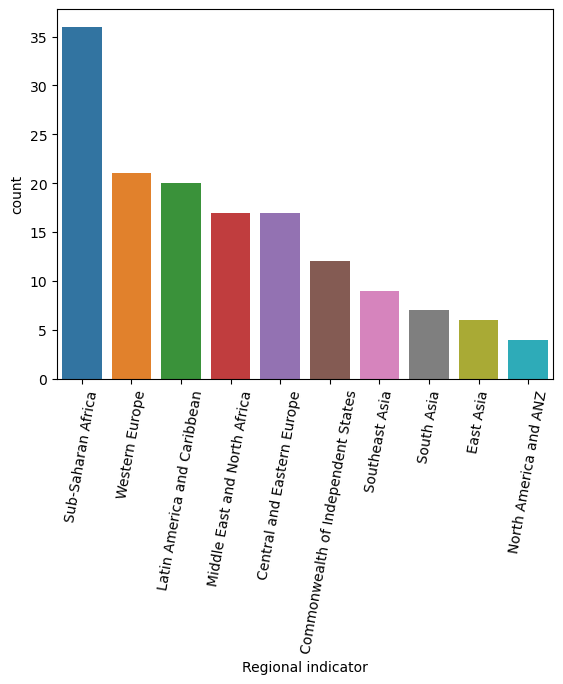

In [23]:
sns.countplot(x="Regional indicator", data=df2021, order=df2021["Regional indicator"].value_counts().index)
plt.xticks(rotation = 80)
plt.show()

### Let's explore the distribution of Healthy life expectancy by our countries

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Healthy life expectancy', ylabel='Count'>

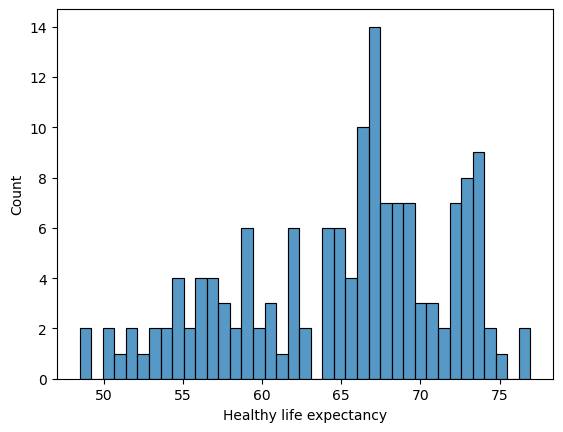

In [24]:
num_countries = df2021['Country name'].nunique()
custom_bins=np.linspace(df2021['Healthy life expectancy'].min(), df2021['Healthy life expectancy'].max(), num=40)
sns.histplot(x='Healthy life expectancy', data=df2021, bins=custom_bins)

### distribution of features using boxplot

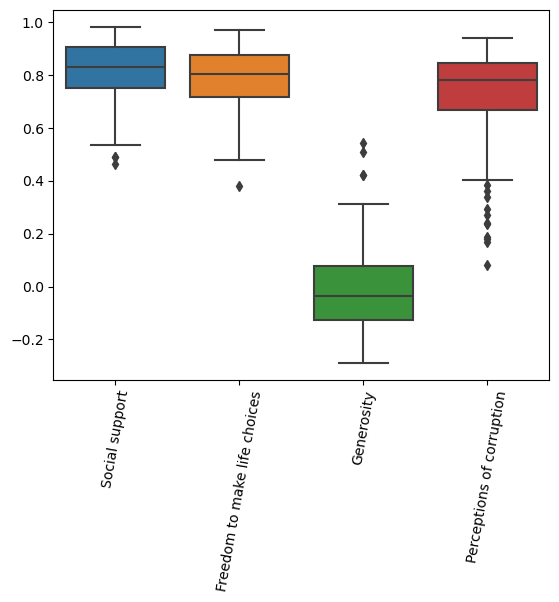

In [25]:
list_features = ["Social support", "Freedom to make life choices", "Generosity", "Perceptions of corruption"]
sns.boxplot(data = df2021.loc[:, list_features], orient = "v")
plt.xticks(rotation = 80)
plt.show()

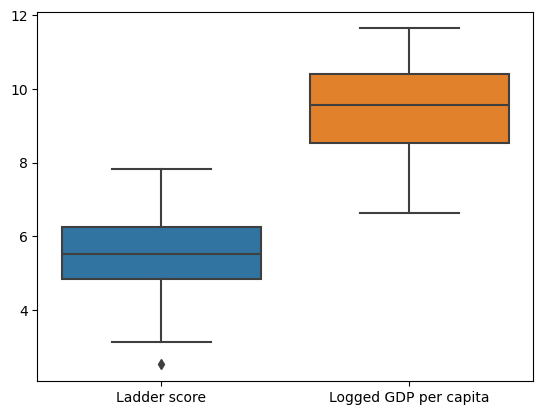

In [26]:
# distribution of features using boxplot
list_features = ["Ladder score", "Logged GDP per capita"]
sns.boxplot(data = df2021.loc[:, list_features], orient = "v")
plt.show()

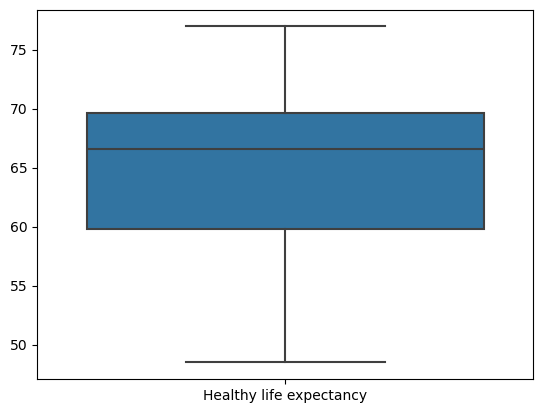

In [27]:
# distribution of healthy life expectancy using boxplot
list_features = ["Healthy life expectancy"]
sns.boxplot(data = df2021.loc[:, list_features], orient = "v")
plt.show()

In [28]:
#Let's get know the distribution of 20 happiest and unhappiest countries by Ladder score
#and rely on that choose which level of Ladder score is proper to choose to our chart
top20 = df2021.nlargest(20, "Ladder score")[["Country name", "Ladder score"]]
top20

,Country name,Ladder score
0,Finland,7.842
1,Denmark,7.620
2,Switzerland,7.571
3,Iceland,7.554
4,Netherlands,7.464
5,Norway,7.392
6,Sweden,7.363
7,Luxembourg,7.324
8,New Zealand,7.277
9,Austria,7.268


In [29]:
bottom20 = df2021.nsmallest(20, "Ladder score")[["Country name", "Ladder score"]]
bottom20

,Country name,Ladder score
148,Afghanistan,2.523
147,Zimbabwe,3.145
146,Rwanda,3.415
145,Botswana,3.467
144,Lesotho,3.512
143,Malawi,3.600
142,Haiti,3.615
141,Tanzania,3.623
140,Yemen,3.658
139,Burundi,3.775


### Happiest and unhappiest countries in 2021

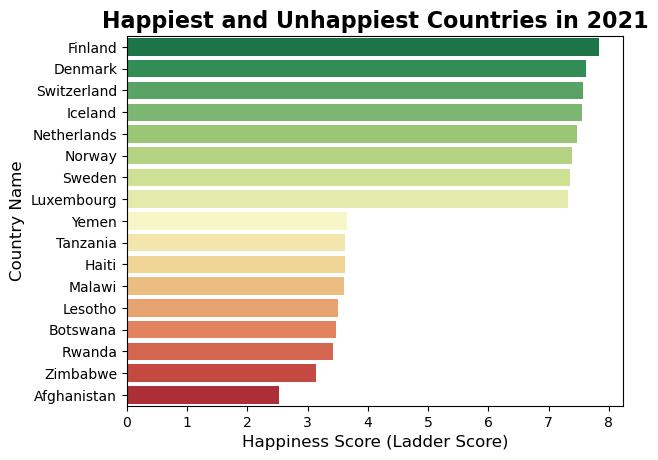

In [30]:
df2021_happiest_unhappiest = df2021[(df2021.loc[:, "Ladder score"] > 7.3) | (df2021.loc[:, "Ladder score"] < 3.7)].sort_values(by="Ladder score", ascending=False)
sns.barplot(x = "Ladder score", y = "Country name", data=df2021_happiest_unhappiest,palette="RdYlGn_r")
plt.title("Happiest and Unhappiest Countries in 2021", fontsize=16, fontweight="bold")
plt.xlabel("Happiness Score (Ladder Score)", fontsize=12)
plt.ylabel("Country Name", fontsize=12)
plt.show()

### Ladder Score Distribution by Regional Indicator

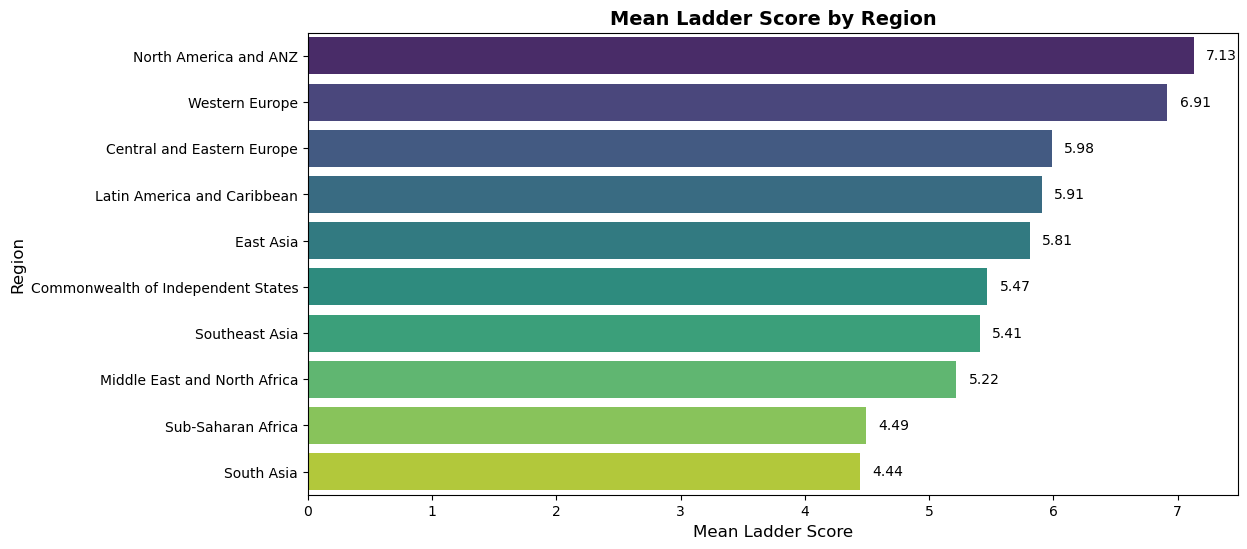

In [31]:
region_mean_ladder = df2021.groupby("Regional indicator")["Ladder score"].mean().reset_index()
region_mean_ladder = region_mean_ladder.sort_values(by="Ladder score", ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=region_mean_ladder, x="Ladder score", y="Regional indicator", palette="viridis")

for i, v in enumerate(region_mean_ladder["Ladder score"]):
    ax.text(v + 0.1, i, f"{v:.2f}", va="center", fontsize=10)

plt.title("Mean Ladder Score by Region", fontsize=14, fontweight="bold")
plt.xlabel("Mean Ladder Score", fontsize=12)
plt.ylabel("Region", fontsize=12)
plt.show()

### Most Generous and Most Ungenerous Countries in 2021

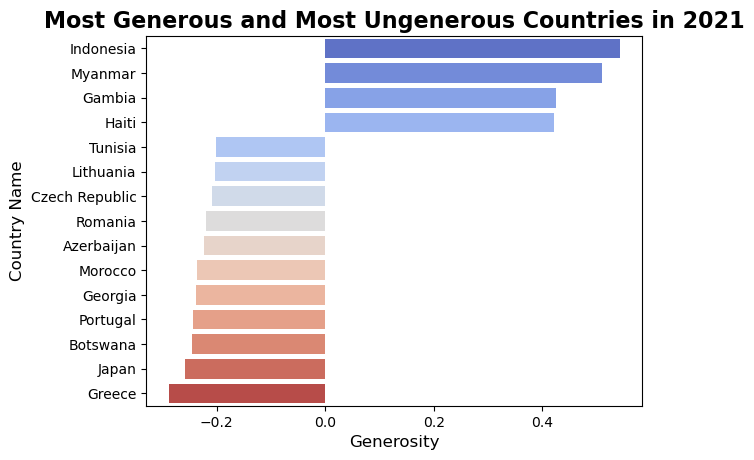

In [32]:
df2021_generous = df2021[(df2021.loc[:, "Generosity"] > 0.4) | (df2021.loc[:, "Generosity"] < -0.2)].sort_values(by="Generosity", ascending=False)
sns.barplot(x = "Generosity", y = "Country name", data=df2021_generous, palette="coolwarm")
plt.title("Most Generous and Most Ungenerous Countries in 2021", fontsize=16, fontweight="bold")
plt.xlabel("Generosity", fontsize=12)
plt.ylabel("Country Name", fontsize=12)
plt.show()

### Relationship Between Happiness and Income

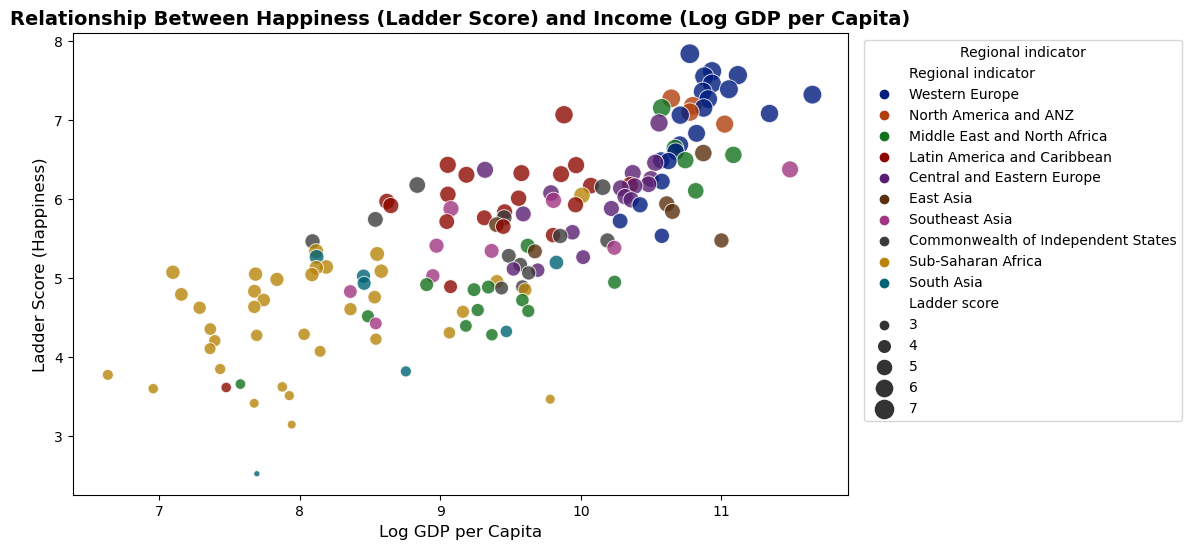

In [33]:
plt.figure(figsize=(10, 6))
# Create scatterplot
sns.scatterplot(data=df2021, x="Logged GDP per capita", y="Ladder score", hue="Regional indicator", size="Ladder score", palette="dark", sizes=(20, 200), alpha=0.8)
# Improve title and labels
plt.title("Relationship Between Happiness (Ladder Score) and Income (Log GDP per Capita)", fontsize=14, fontweight="bold")
plt.xlabel("Log GDP per Capita", fontsize=12)
plt.ylabel("Ladder Score (Happiness)", fontsize=12)
plt.legend(title="Regional indicator", loc='upper right', bbox_to_anchor=(1.44, 1)) 
plt.show()

### Relationship Between Happiness and Freedom

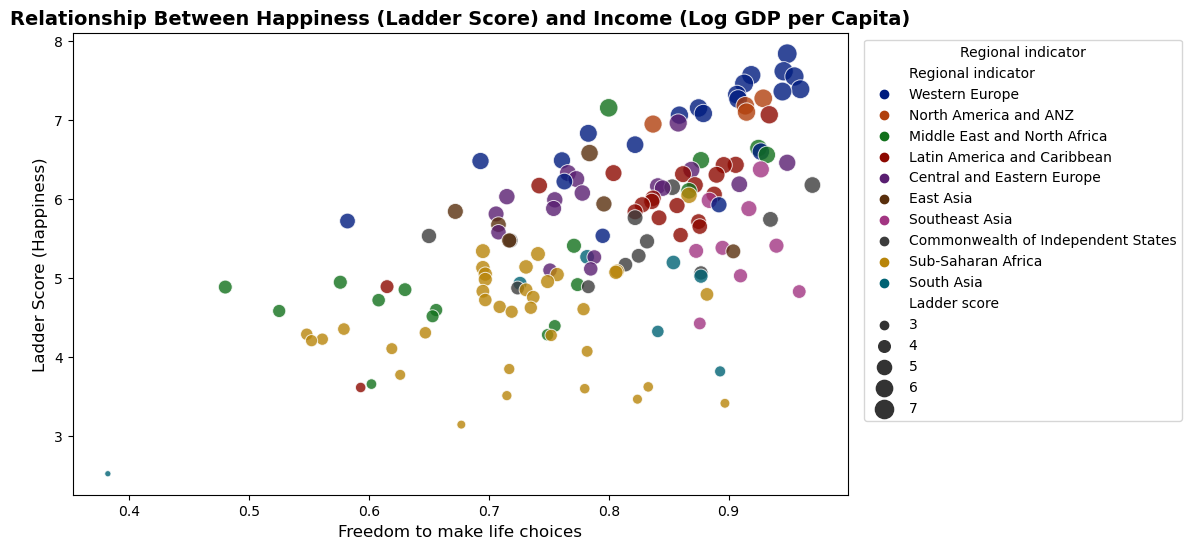

In [34]:
plt.figure(figsize=(10, 6))
# Create scatterplot
sns.scatterplot(data=df2021, x="Freedom to make life choices", y="Ladder score", hue="Regional indicator", size="Ladder score", palette="dark", sizes=(20, 200), alpha=0.8)
# Improve title and labels
plt.title("Relationship Between Happiness (Ladder Score) and Income (Log GDP per Capita)", fontsize=14, fontweight="bold")
plt.xlabel("Freedom to make life choices", fontsize=12)
plt.ylabel("Ladder Score (Happiness)", fontsize=12)
plt.legend(title="Regional indicator", loc='upper right', bbox_to_anchor=(1.44, 1)) 
plt.show()

### Relationship Between Happiness and Corruption

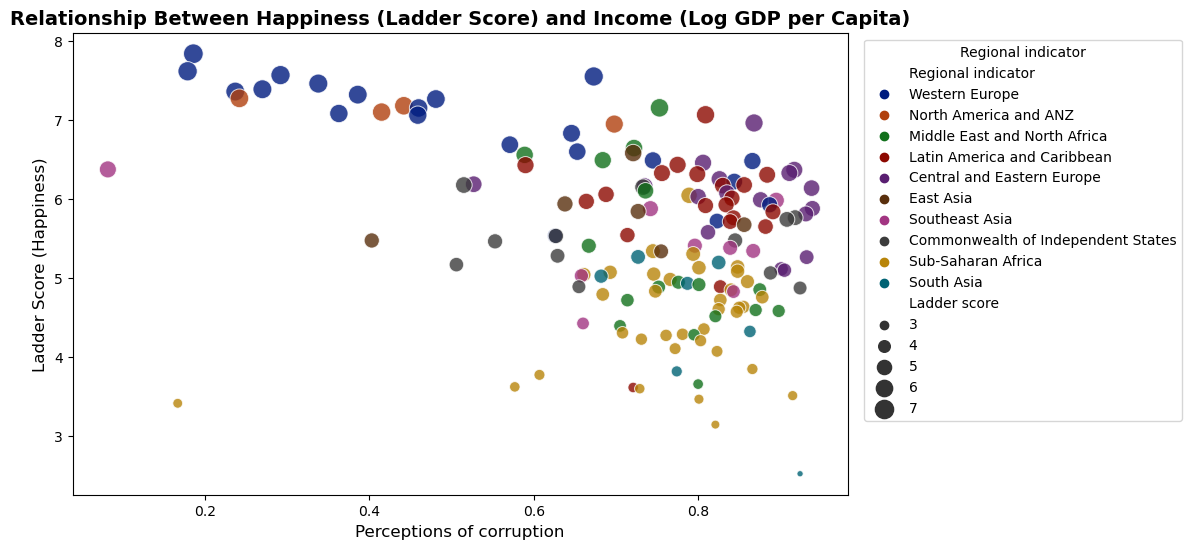

In [35]:
plt.figure(figsize=(10, 6))
# Create scatterplot
sns.scatterplot(data=df2021, x="Perceptions of corruption", y="Ladder score", hue="Regional indicator", size="Ladder score", palette="dark", sizes=(20, 200), alpha=0.8)
# Improve title and labels
plt.title("Relationship Between Happiness (Ladder Score) and Income (Log GDP per Capita)", fontsize=14, fontweight="bold")
plt.xlabel("Perceptions of corruption", fontsize=12)
plt.ylabel("Ladder Score (Happiness)", fontsize=12)
plt.legend(title="Regional indicator", loc='upper right', bbox_to_anchor=(1.44, 1))  
plt.show()